# 🛒 Quick-Commerce Sales, Customer & Delivery Analytics with AI
### Blinkit-Style Dark-Store Analysis | IBM SkillsBuild – Data Analytics with AI Internship 2026 (AICTE × BharatCares)

---
## 1. Project Overview

**Business context.** Quick-commerce platforms (Blinkit, Zepto, Swiggy Instamart) promise groceries in ~10–20 minutes.
Their profitability depends on three things at once: **what customers buy**, **who keeps coming back**, and **whether the
promised delivery time is actually met**.

**Problem statement.** A quick-commerce operator has a year of order-level data (Jan–Dec 2025) but no unified view of
revenue drivers, customer value, and delivery reliability. This project builds an end-to-end analytics + AI workflow to answer:

1. Which categories, cities and time slots drive revenue?
2. Who are our most valuable customers, and who is about to churn?
3. What causes late deliveries, and can we **predict them before they happen**?
4. How many orders should we expect tomorrow (for rider & stock planning)?
5. Are discounts actually increasing basket size, or just leaking margin?

**AI / ML components used**
| Component | Technique | Business use |
|---|---|---|
| Customer segmentation | RFM + K-Means clustering | Targeted retention & rewards |
| Delay prediction | Logistic Regression, Random Forest, Gradient Boosting | Proactive ETA & rider allocation |
| Demand forecasting | Ridge regression (trend + calendar) vs. Random Forest & naive baselines | Staffing & inventory planning |
| Automated insight engine | Statistical rule-based narrative generation | Auto-written management summary |

**Tech stack:** Python · Pandas · NumPy · Matplotlib · Seaborn · Scikit-learn · Jupyter

> ⚠️ **Data note:** The real Blinkit order-level data is not public. This notebook therefore uses a **synthetic, seeded
> (reproducible) dataset** that mimics quick-commerce behaviour (peak hours, rain effects, festive spike, churn, dirty records).
> To run the same pipeline on a real CSV, set `REAL_DATA_PATH` in Section 3 (same column names).

## 2. Setup – Libraries & Configuration

In [5]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             roc_curve, confusion_matrix, ConfusionMatrixDisplay, silhouette_score,
                             mean_absolute_error)
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold", "axes.titlesize": 13})
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

os.makedirs("charts", exist_ok=True)
os.makedirs("data", exist_ok=True)

def save_fig(name):
    """Save the current figure to charts/ and display it."""
    plt.tight_layout()
    plt.savefig(f"charts/{name}.png", dpi=110, bbox_inches="tight")
    plt.show()

def inr(x):
    return f"₹{x:,.0f}"

print("Libraries loaded ✔")

ModuleNotFoundError: No module named 'matplotlib'

## 3. Dataset

The generator below creates **~32,000 orders from ~3,000 customers across 6 cities** (Jan–Dec 2025) with realistic patterns:
evening & morning peaks, weekend uplift, festive-season (Oct–Nov) spike and discounts, monsoon rain, distance-based delivery
times, customer churn, plus **deliberately dirty records** (duplicates, missing values, logging errors) so the cleaning step is real.

| Column | Description |
|---|---|
| `order_id`, `customer_id` | Identifiers |
| `order_datetime` | Order timestamp |
| `city`, `age_group`, `is_member` | Customer attributes (member = paid subscription) |
| `category` | Main product category of the basket |
| `items_count`, `discount_pct`, `order_value` | Basket size, discount %, final amount paid (₹) |
| `payment_method` | UPI, Card, COD, Wallet, Pay Later |
| `distance_km` | Dark-store → customer distance |
| `is_raining`, `prep_time_min` | Weather flag, packing time |
| `promised_time_min`, `delivery_time_min` | ETA shown vs. actual delivery time |
| `rating`, `refund_requested` | Customer feedback |

In [ ]:
def generate_dataset(n_customers=3000, n_orders=32000, seed=42):
    """Create a reproducible quick-commerce order dataset (with injected data-quality issues)."""
    rng = np.random.default_rng(seed)

    cities = ["Delhi NCR", "Mumbai", "Bengaluru", "Hyderabad", "Pune", "Kolkata"]
    city_p = [0.28, 0.22, 0.20, 0.12, 0.10, 0.08]
    traffic = {"Delhi NCR": 1.05, "Mumbai": 1.20, "Bengaluru": 1.25, "Hyderabad": 1.00, "Pune": 0.95, "Kolkata": 1.05}
    rain_p = {"Delhi NCR": 0.18, "Mumbai": 0.30, "Bengaluru": 0.22, "Hyderabad": 0.16, "Pune": 0.20, "Kolkata": 0.26}

    # ---- customers ----
    cust = pd.DataFrame({
        "customer_id": [f"C{i:05d}" for i in range(1, n_customers + 1)],
        "city": rng.choice(cities, size=n_customers, p=city_p),
        "age_group": rng.choice(["18-24", "25-34", "35-44", "45+"], size=n_customers, p=[.28, .42, .20, .10]),
        "is_member": rng.random(n_customers) < 0.35,
    })
    prop = rng.gamma(1.1, 1.0, n_customers) * np.where(cust["is_member"], 1.7, 1.0)   # ordering propensity
    churn_flag = rng.random(n_customers) < 0.28                                        # ~28% stop ordering mid-year
    cust["churn_day"] = np.where(churn_flag, rng.integers(60, 320, n_customers), 10_000)

    # ---- order dates: growth trend + weekend uplift + festive season ----
    days = pd.date_range("2025-01-01", "2025-12-31")
    t = np.arange(len(days))
    w = 1 + 0.9 * t / t.max()
    w = w * np.where(days.dayofweek >= 5, 1.18, 1.0)
    w = w * np.where((days >= "2025-10-10") & (days <= "2025-11-05"), 1.25, 1.0)
    day_idx = rng.choice(len(days), size=n_orders, p=w / w.sum())

    # ---- which customer placed the order (respecting churn) ----
    p_c = prop / prop.sum()
    cust_idx = rng.choice(n_customers, size=n_orders, p=p_c)
    for _ in range(12):
        bad = day_idx > cust["churn_day"].values[cust_idx]
        if not bad.any():
            break
        cust_idx[bad] = rng.choice(n_customers, size=bad.sum(), p=p_c)
    bad = day_idx > cust["churn_day"].values[cust_idx]
    day_idx[bad] = np.minimum(day_idx[bad], cust["churn_day"].values[cust_idx][bad])

    # ---- time of day (morning + evening peaks) ----
    hour_w = np.array([2, 1.2, .8, .5, .4, .6, 1.5, 3.5, 5.5, 5.0, 3.5, 3.0,
                       3.5, 3.5, 3.0, 3.2, 3.8, 4.8, 6.5, 8.0, 8.5, 7.0, 4.5, 3.0])
    hour = rng.choice(24, size=n_orders, p=hour_w / hour_w.sum())
    minute = rng.integers(0, 60, n_orders)
    order_dt = days[day_idx] + pd.to_timedelta(hour, unit="h") + pd.to_timedelta(minute, unit="m")

    o = pd.DataFrame({
        "order_id": [f"ORD{100000 + i}" for i in range(n_orders)],
        "customer_id": cust["customer_id"].values[cust_idx],
        "order_datetime": order_dt,
        "city": cust["city"].values[cust_idx],
        "is_member": cust["is_member"].values[cust_idx],
        "age_group": cust["age_group"].values[cust_idx],
    })

    # ---- category (late-night skews to snacks/drinks; morning to dairy/veg) ----
    cats = ["Fruits & Vegetables", "Dairy & Bread", "Snacks & Munchies", "Cold Drinks & Juices",
            "Instant & Frozen Food", "Atta, Rice & Dal", "Personal Care", "Household & Cleaning",
            "Chocolates & Sweets", "Baby & Pet Care", "Electronics & Accessories"]
    base_p = np.array([.17, .16, .11, .08, .08, .09, .06, .07, .07, .05, .06])
    unit_price = np.array([70, 55, 65, 60, 95, 140, 150, 120, 80, 210, 320], dtype=float)
    P = np.tile(base_p, (n_orders, 1))
    late = (hour >= 22) | (hour <= 3)
    P[np.ix_(late, [2, 3, 8])] *= 2.4
    P[np.ix_(late, [0, 5])] *= 0.4
    morning = (hour >= 6) & (hour <= 10)
    P[np.ix_(morning, [0, 1])] *= 1.6
    P = P / P.sum(axis=1, keepdims=True)
    cat_idx = (P.cumsum(axis=1) > rng.random((n_orders, 1))).argmax(axis=1)
    o["category"] = np.array(cats)[cat_idx]

    # ---- basket, discount, value ----
    items = np.clip(1 + rng.poisson(2.3, n_orders), 1, 18)
    price = unit_price[cat_idx] * rng.lognormal(0, 0.35, n_orders)
    gross = items * price
    festive = ((order_dt >= "2025-10-10") & (order_dt <= "2025-11-05"))
    disc_choices = np.array([0, 5, 10, 15, 20])
    disc_p = np.where(festive[:, None], [[.30, .15, .25, .15, .15]], [[.52, .17, .17, .09, .05]])
    disc = disc_choices[(disc_p.cumsum(axis=1) > rng.random((n_orders, 1))).argmax(axis=1)]
    o["items_count"] = items
    o["discount_pct"] = disc
    o["order_value"] = np.round(gross * (1 - disc / 100), 2)
    o["payment_method"] = rng.choice(["UPI", "Credit/Debit Card", "Cash on Delivery", "Wallet", "Pay Later"],
                                     size=n_orders, p=[.52, .18, .12, .10, .08])

    # ---- delivery physics: distance, traffic, rain, peak hours ----
    dist = np.clip(rng.gamma(2.2, 0.75, n_orders), 0.3, 7.0)
    month, hr = order_dt.month.values, order_dt.hour.values
    rain = rng.random(n_orders) < (np.array([rain_p[c] for c in o["city"]]) * np.where(np.isin(month, [6, 7, 8, 9]), 1.7, 0.6))
    peak = np.isin(hr, [8, 9, 19, 20, 21])
    tr = np.array([traffic[c] for c in o["city"]])
    prep = np.clip(rng.normal(3.0 + 0.22 * items, 1.0), 1.5, None)
    travel = dist * 2.6 * tr * np.where(rain, 1.30, 1.0) * np.where(peak, 1.18, 1.0)
    dtime = np.clip(prep + travel + rng.normal(1.0, 1.6, n_orders), 5, None)
    promised = np.where(dist < 1.5, 10, np.where(dist < 3.0, 14, np.where(dist < 4.5, 18, 22)))
    o["distance_km"] = np.round(dist, 2)
    o["is_raining"] = rain
    o["prep_time_min"] = np.round(prep, 1)
    o["promised_time_min"] = promised
    o["delivery_time_min"] = np.round(dtime, 1)

    # ---- feedback depends on lateness ----
    delay = np.maximum(dtime - promised, 0)
    rating = 4.75 - 0.10 * delay - 0.25 * (delay > 0) + rng.normal(0, 0.55, n_orders)
    o["rating"] = np.clip(np.round(rating), 1, 5).astype(float)
    o["refund_requested"] = rng.random(n_orders) < (0.015 + 0.07 * (delay > 3))

    # ---- inject realistic data-quality problems ----
    o.loc[rng.random(n_orders) < 0.12, "rating"] = np.nan                   # customers skip rating
    o.loc[rng.random(n_orders) < 0.008, "payment_method"] = np.nan          # logging gaps
    out_idx = rng.choice(n_orders, 40, replace=False)
    o.loc[out_idx, "delivery_time_min"] = rng.uniform(150, 420, 40).round(1)  # GPS/app logging errors
    dups = o.sample(60, random_state=seed)                                    # duplicated rows
    o = pd.concat([o, dups], ignore_index=True).sample(frac=1, random_state=seed).reset_index(drop=True)
    return o


# To use a REAL dataset instead, put the CSV path here (must contain the same columns as above)
REAL_DATA_PATH = None

if REAL_DATA_PATH:
    raw = pd.read_csv(REAL_DATA_PATH, parse_dates=["order_datetime"])
else:
    raw = generate_dataset(seed=SEED)

raw.to_csv("data/blinkit_orders_raw.csv", index=False)
print(f"Raw dataset: {raw.shape[0]:,} rows × {raw.shape[1]} columns")
raw.head()

Raw dataset: 32,060 rows × 18 columns


,order_id,customer_id,order_datetime,city,is_member,age_group,category,items_count,discount_pct,order_value,payment_method,distance_km,is_raining,prep_time_min,promised_time_min,delivery_time_min,rating,refund_requested
0,ORD109672,C02426,2025-06-10 07:31:00,Hyderabad,False,25-34,Instant & Frozen Food,2,0,200.17,UPI,1.12,True,5.60,10,11.10,5.00,False
1,ORD126137,C01833,2025-04-10 16:49:00,Mumbai,True,25-34,Cold Drinks & Juices,2,0,119.71,UPI,0.53,False,6.10,10,8.10,5.00,False
2,ORD129955,C01277,2025-02-24 19:01:00,Delhi NCR,False,25-34,"Atta, Rice & Dal",1,0,72.83,UPI,3.16,False,2.90,18,12.60,4.00,False
3,ORD118879,C00174,2025-12-05 19:25:00,Kolkata,False,45+,Dairy & Bread,3,0,344.18,Wallet,1.56,True,4.70,14,12.40,NaN,False
4,ORD122479,C00547,2025-06-14 19:33:00,Mumbai,True,25-34,Dairy & Bread,6,0,604.36,Credit/Debit Card,1.41,False,5.10,10,10.30,5.00,False


## 4. Data Understanding

In [ ]:
print("Date range :", raw["order_datetime"].min(), "→", raw["order_datetime"].max())
print("Customers  :", raw["customer_id"].nunique())
print("Cities     :", raw["city"].nunique())
print()
raw.info()

Date range : 2025-01-01 00:36:00 → 2025-12-31 23:47:00
Customers  : 2683
Cities     : 6

<class 'pandas.DataFrame'>
RangeIndex: 32060 entries, 0 to 32059
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   order_id           32060 non-null  str           
 1   customer_id        32060 non-null  str           
 2   order_datetime     32060 non-null  datetime64[us]
 3   city               32060 non-null  str           
 4   is_member          32060 non-null  bool          
 5   age_group          32060 non-null  str           
 6   category           32060 non-null  str           
 7   items_count        32060 non-null  int64         
 8   discount_pct       32060 non-null  int64         
 9   order_value        32060 non-null  float64       
 10  payment_method     31801 non-null  str           
 11  distance_km        32060 non-null  float64       
 12  is_raining         32060 non-null  boo

In [ ]:
raw.describe(include="all").T.iloc[:, :8]

,count,unique,top,freq,mean,min,25%,50%
order_id,32060,32000,ORD102561,2,NaN,NaN,NaN,NaN
customer_id,32060,2683,C00226,139,NaN,NaN,NaN,NaN
order_datetime,32060,NaN,NaN,NaN,2025-07-24 01:43:04.908920,2025-01-01 00:36:00,2025-04-29 16:02:45,2025-08-04 09:22:30
city,32060,6,Delhi NCR,8569,NaN,NaN,NaN,NaN
is_member,32060,2,False,17258,NaN,NaN,NaN,NaN
age_group,32060,4,25-34,13394,NaN,NaN,NaN,NaN
category,32060,11,Dairy & Bread,5389,NaN,NaN,NaN,NaN
items_count,"32,060.00",NaN,NaN,NaN,3.30,1.00,2.00,3.00
discount_pct,"32,060.00",NaN,NaN,NaN,5.25,0.00,0.00,5.00
order_value,"32,060.00",NaN,NaN,NaN,342.54,17.88,147.67,242.49


## 5. Data Cleaning

Every cleaning decision is documented so it can be defended in review:

| Issue | Detection | Decision |
|---|---|---|
| Duplicate rows | `duplicated()` | Drop (same `order_id` cannot occur twice) |
| Missing `payment_method` | `isna()` | Fill with `"Unknown"` (keeps the order's revenue) |
| Missing `rating` | `isna()` | **Keep as NaN** – customers simply did not rate; imputing would bias satisfaction metrics |
| Delivery time outliers | Business rule: quick-commerce delivery > 90 min is a logging error | Remove |

In [ ]:
missing = raw.isna().sum().to_frame("missing_count")
missing["missing_%"] = (missing["missing_count"] / len(raw) * 100).round(2)
print("Missing values (before cleaning):")
display(missing[missing["missing_count"] > 0])

n_dups = raw.duplicated().sum()
n_outliers = (raw["delivery_time_min"] > 90).sum()
print(f"\nDuplicate rows            : {n_dups}")
print(f"Delivery time > 90 min    : {n_outliers}")

Missing values (before cleaning):


,missing_count,missing_%
payment_method,259,0.81
rating,3775,11.77



Duplicate rows            : 60
Delivery time > 90 min    : 40


In [ ]:
df = raw.copy()
df = df.drop_duplicates()
df["payment_method"] = df["payment_method"].fillna("Unknown")
df = df[df["delivery_time_min"] <= 90].copy()
df["order_datetime"] = pd.to_datetime(df["order_datetime"])
df = df.reset_index(drop=True)

summary = pd.DataFrame({
    "Stage": ["Raw", "After cleaning"],
    "Rows": [len(raw), len(df)],
    "Missing cells": [int(raw.isna().sum().sum()), int(df.isna().sum().sum())],
    "Duplicates": [int(raw.duplicated().sum()), int(df.duplicated().sum())],
    "Max delivery time (min)": [raw["delivery_time_min"].max(), df["delivery_time_min"].max()],
})
display(summary)
print("Remaining missing cells are all in `rating` (intentionally kept).")

,Stage,Rows,Missing cells,Duplicates,Max delivery time (min)
0,Raw,32060,4034,60,408.40
1,After cleaning,31960,3763,0,42.30


Remaining missing cells are all in `rating` (intentionally kept).


## 6. Feature Engineering
Time features, delivery-performance flags and discount economics used across the analysis and models.

In [ ]:
dt = df["order_datetime"].dt
df["order_date"] = dt.normalize()
df["month"] = dt.month
df["month_name"] = dt.strftime("%b")
df["weekday"] = dt.day_name()
df["dow"] = dt.dayofweek
df["is_weekend"] = (df["dow"] >= 5).astype(int)
df["hour"] = dt.hour
df["day_part"] = pd.cut(df["hour"], bins=[-1, 5, 11, 16, 21, 23],
                        labels=["Late Night", "Morning", "Afternoon", "Evening", "Night"]).astype(str)
df["is_peak"] = df["hour"].isin([8, 9, 19, 20, 21]).astype(int)

df["delay_min"] = (df["delivery_time_min"] - df["promised_time_min"]).clip(lower=0)
df["is_delayed"] = (df["delivery_time_min"] > df["promised_time_min"]).astype(int)
df["gross_value"] = df["order_value"] / (1 - df["discount_pct"] / 100)
df["discount_amount"] = df["gross_value"] - df["order_value"]

df[["order_id", "order_datetime", "hour", "day_part", "is_peak", "delay_min", "is_delayed",
    "gross_value", "discount_amount"]].head()

,order_id,order_datetime,hour,day_part,is_peak,delay_min,is_delayed,gross_value,discount_amount
0,ORD109672,2025-06-10 07:31:00,7,Morning,0,1.10,1,200.17,0.00
1,ORD126137,2025-04-10 16:49:00,16,Afternoon,0,0.00,0,119.71,0.00
2,ORD129955,2025-02-24 19:01:00,19,Evening,1,0.00,0,72.83,0.00
3,ORD118879,2025-12-05 19:25:00,19,Evening,1,0.00,0,344.18,0.00
4,ORD122479,2025-06-14 19:33:00,19,Evening,1,0.30,1,604.36,0.00


## 7. Business KPIs (Executive Snapshot)

In [ ]:
total_rev = df["order_value"].sum()
n_orders = len(df)
n_cust = df["customer_id"].nunique()
aov = df["order_value"].mean()
on_time = 1 - df["is_delayed"].mean()
avg_delivery = df["delivery_time_min"].mean()
avg_rating = df["rating"].mean()
refund_rate = df["refund_requested"].mean()
disc_leak = df["discount_amount"].sum()
disc_leak_pct = disc_leak / df["gross_value"].sum()

kpis = pd.DataFrame({
    "KPI": ["Total revenue", "Total orders", "Unique customers", "Average order value (AOV)",
            "Orders per customer", "On-time delivery rate", "Avg delivery time (min)",
            "Avg customer rating (of rated orders)", "Refund request rate", "Discount given (₹)", "Discount as % of gross sales"],
    "Value": [inr(total_rev), f"{n_orders:,}", f"{n_cust:,}", inr(aov), f"{n_orders / n_cust:.1f}",
              f"{on_time:.1%}", f"{avg_delivery:.1f}", f"{avg_rating:.2f} / 5", f"{refund_rate:.1%}",
              inr(disc_leak), f"{disc_leak_pct:.1%}"]
})
kpis

,KPI,Value
0,Total revenue,"₹10,945,839"
1,Total orders,"31,960"
2,Unique customers,"2,683"
3,Average order value (AOV),₹342
4,Orders per customer,11.9
5,On-time delivery rate,82.5%
6,Avg delivery time (min),10.2
7,Avg customer rating (of rated orders),4.60 / 5
8,Refund request rate,1.7%
9,Discount given (₹),"₹608,165"


## 8. Exploratory Data Analysis
### 8.1 Revenue & order trend over the year

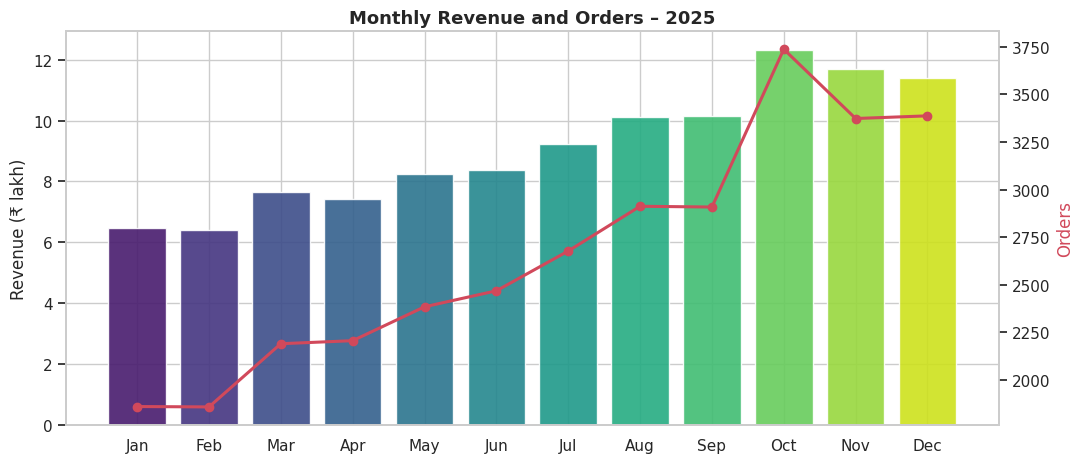

Revenue grew 76% from Jan to Dec. Best month: Oct.


In [ ]:
monthly = (df.groupby(df["order_datetime"].dt.to_period("M"))
             .agg(revenue=("order_value", "sum"), orders=("order_id", "count"), aov=("order_value", "mean"))
             .reset_index())
monthly["month"] = monthly["order_datetime"].dt.strftime("%b")

fig, ax1 = plt.subplots(figsize=(11, 4.8))
ax1.bar(monthly["month"], monthly["revenue"] / 1e5, color=sns.color_palette("viridis", 12), alpha=0.9)
ax1.set_ylabel("Revenue (₹ lakh)")
ax1.set_title("Monthly Revenue and Orders – 2025")
ax2 = ax1.twinx()
ax2.plot(monthly["month"], monthly["orders"], color="#d1495b", marker="o", linewidth=2.2)
ax2.set_ylabel("Orders", color="#d1495b")
ax2.grid(False)
save_fig("01_monthly_trend")

growth = monthly["revenue"].iloc[-1] / monthly["revenue"].iloc[0] - 1
best_month = monthly.loc[monthly["revenue"].idxmax(), "month"]
print(f"Revenue grew {growth:.0%} from Jan to Dec. Best month: {best_month}.")

### 8.2 Category performance

,revenue,orders,aov,avg_discount,delay_rate,revenue_share_%
category,,,,,,
Electronics & Accessories,"1,981,446.30",1839,"1,077.46",5.25,0.18,18.10
Fruits & Vegetables,"1,245,737.39",5330,233.72,5.36,0.18,11.38
"Atta, Rice & Dal","1,128,336.80",2450,460.55,5.25,0.16,10.31
Baby & Pet Care,"1,035,543.39",1516,683.08,5.10,0.17,9.46
Dairy & Bread,"985,258.02",5377,183.24,5.31,0.19,9.00
Personal Care,"935,914.57",1857,503.99,5.33,0.17,8.55
Snacks & Munchies,"831,792.18",3812,218.20,5.11,0.17,7.60
Household & Cleaning,"824,722.83",2072,398.03,5.28,0.16,7.53
Instant & Frozen Food,"759,098.95",2405,315.63,5.22,0.18,6.94


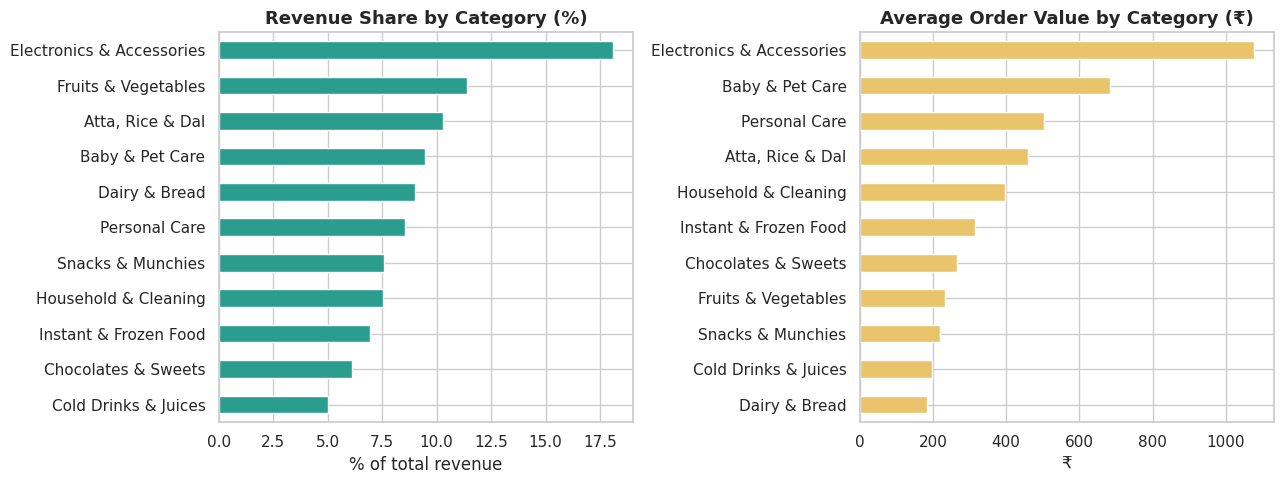

In [ ]:
cat = (df.groupby("category")
         .agg(revenue=("order_value", "sum"), orders=("order_id", "count"), aov=("order_value", "mean"),
              avg_discount=("discount_pct", "mean"), delay_rate=("is_delayed", "mean"))
         .sort_values("revenue", ascending=False))
cat["revenue_share_%"] = cat["revenue"] / cat["revenue"].sum() * 100
display(cat.round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cat["revenue_share_%"].sort_values().plot.barh(ax=axes[0], color="#2a9d8f")
axes[0].set_title("Revenue Share by Category (%)")
axes[0].set_xlabel("% of total revenue"); axes[0].set_ylabel("")
cat["aov"].sort_values().plot.barh(ax=axes[1], color="#e9c46a")
axes[1].set_title("Average Order Value by Category (₹)")
axes[1].set_xlabel("₹"); axes[1].set_ylabel("")
save_fig("02_category")

### 8.3 City performance – revenue vs. delivery reliability

,orders,revenue,aov,avg_delivery,delay_rate,rating,refund_rate
city,,,,,,,
Delhi NCR,8538,"2,909,265.58",340.74,9.86,0.14,4.62,0.01
Bengaluru,6847,"2,345,635.00",342.58,10.91,0.26,4.58,0.02
Mumbai,6521,"2,255,193.06",345.83,10.74,0.24,4.57,0.02
Hyderabad,4181,"1,466,287.12",350.70,9.59,0.10,4.63,0.02
Kolkata,2913,"997,260.88",342.35,10.01,0.14,4.62,0.02
Pune,2960,"972,197.64",328.44,9.47,0.09,4.64,0.01


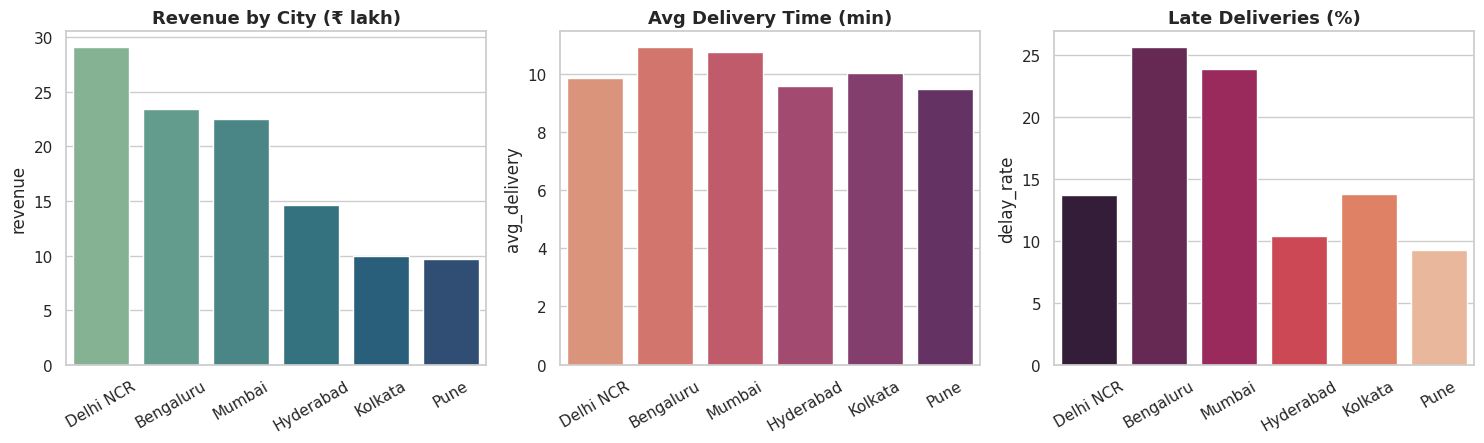

In [ ]:
city = (df.groupby("city")
          .agg(orders=("order_id", "count"), revenue=("order_value", "sum"), aov=("order_value", "mean"),
               avg_delivery=("delivery_time_min", "mean"), delay_rate=("is_delayed", "mean"),
               rating=("rating", "mean"), refund_rate=("refund_requested", "mean"))
          .sort_values("revenue", ascending=False))
display(city.round(3))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
sns.barplot(x=city.index, y=city["revenue"] / 1e5, ax=axes[0], palette="crest")
axes[0].set_title("Revenue by City (₹ lakh)"); axes[0].set_xlabel(""); axes[0].tick_params(axis="x", rotation=30)
sns.barplot(x=city.index, y=city["avg_delivery"], ax=axes[1], palette="flare")
axes[1].set_title("Avg Delivery Time (min)"); axes[1].set_xlabel(""); axes[1].tick_params(axis="x", rotation=30)
sns.barplot(x=city.index, y=city["delay_rate"] * 100, ax=axes[2], palette="rocket")
axes[2].set_title("Late Deliveries (%)"); axes[2].set_xlabel(""); axes[2].tick_params(axis="x", rotation=30)
save_fig("03_city")

### 8.4 When do customers order? (weekday × hour heatmap)

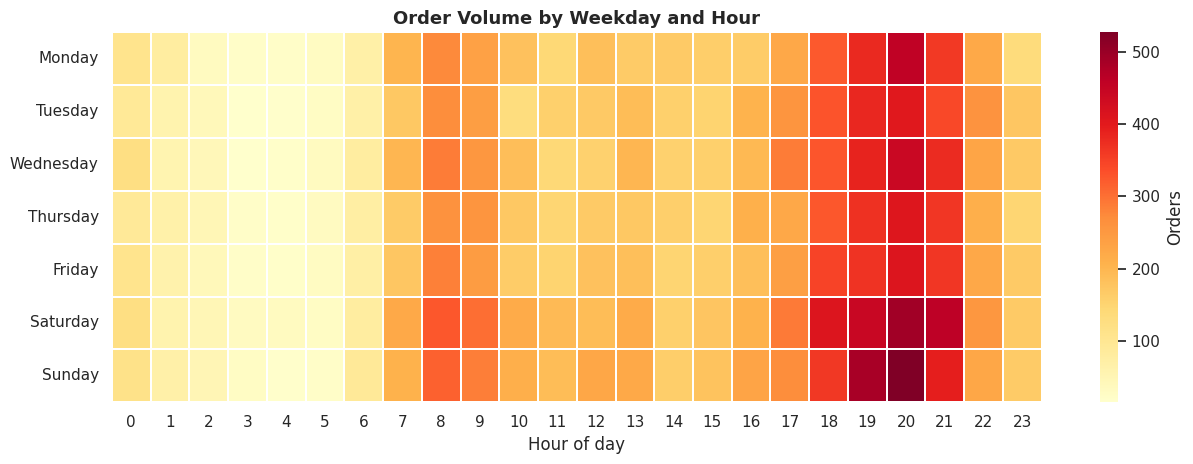

Busiest hour: 20:00. Peak windows (8-9am, 7-9pm) carry 39% of all orders.


In [ ]:
order_days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
heat = (df.pivot_table(index="weekday", columns="hour", values="order_id", aggfunc="count")
          .reindex(order_days))

plt.figure(figsize=(13, 4.8))
sns.heatmap(heat, cmap="YlOrRd", linewidths=0.3, cbar_kws={"label": "Orders"})
plt.title("Order Volume by Weekday and Hour")
plt.xlabel("Hour of day"); plt.ylabel("")
save_fig("04_heatmap")

hourly = df.groupby("hour").size()
peak_hour = hourly.idxmax()
peak_share = df["is_peak"].mean()
print(f"Busiest hour: {peak_hour}:00. Peak windows (8-9am, 7-9pm) carry {peak_share:.0%} of all orders.")

### 8.5 Payments and discount effectiveness
**Question:** do bigger discounts create bigger baskets, or just reduce what we earn per order?

,discount_pct,orders,gross_basket,net_aov,items
0,0,15951,360.66,360.66,3.30
1,5,5351,357.25,339.39,3.28
2,10,5689,369.00,332.10,3.32
3,15,3056,362.58,308.19,3.31
4,20,1913,356.65,285.32,3.30


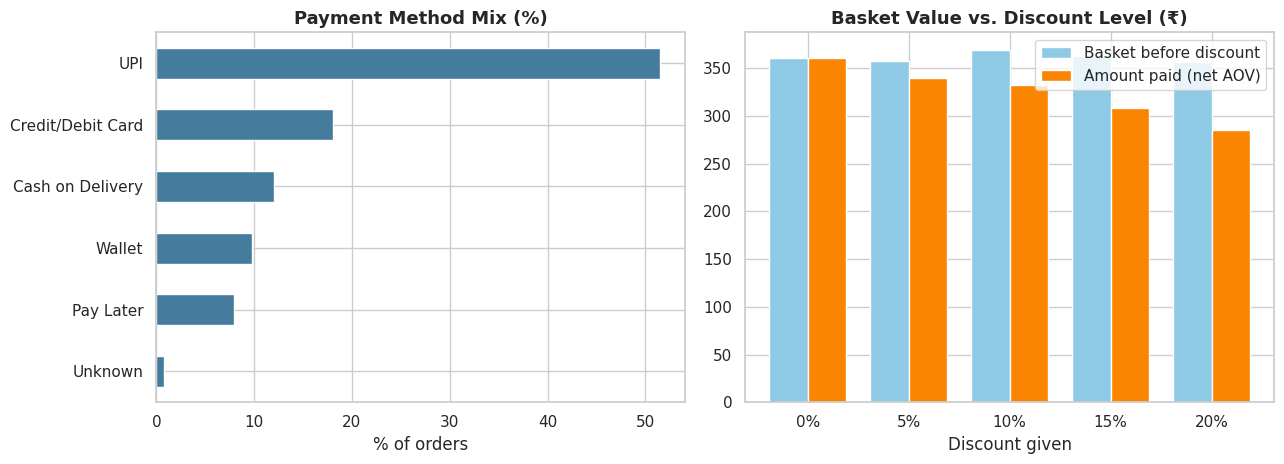

Correlation between discount % and basket size: +0.002  → discounts do not lift basket value; they only reduce net revenue.
Total discount given: ₹608,165 (5.3% of gross sales).


In [ ]:
pay = df["payment_method"].value_counts(normalize=True) * 100
disc = (df.groupby("discount_pct")
          .agg(orders=("order_id", "count"), gross_basket=("gross_value", "mean"),
               net_aov=("order_value", "mean"), items=("items_count", "mean"))
          .reset_index())
display(disc.round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
pay.sort_values().plot.barh(ax=axes[0], color="#457b9d")
axes[0].set_title("Payment Method Mix (%)"); axes[0].set_ylabel(""); axes[0].set_xlabel("% of orders")
x = np.arange(len(disc)); wd = 0.38
axes[1].bar(x - wd / 2, disc["gross_basket"], wd, label="Basket before discount", color="#8ecae6")
axes[1].bar(x + wd / 2, disc["net_aov"], wd, label="Amount paid (net AOV)", color="#fb8500")
axes[1].set_xticks(x); axes[1].set_xticklabels([f"{d}%" for d in disc["discount_pct"]])
axes[1].set_title("Basket Value vs. Discount Level (₹)"); axes[1].set_xlabel("Discount given"); axes[1].legend()
save_fig("05_payment_discount")

corr = df[["discount_pct", "gross_value"]].corr().iloc[0, 1]
print(f"Correlation between discount % and basket size: {corr:+.3f}  → discounts do not lift basket value; they only reduce net revenue.")
print(f"Total discount given: {inr(disc_leak)} ({disc_leak_pct:.1%} of gross sales).")

### 8.6 What drives delivery time and late deliveries?

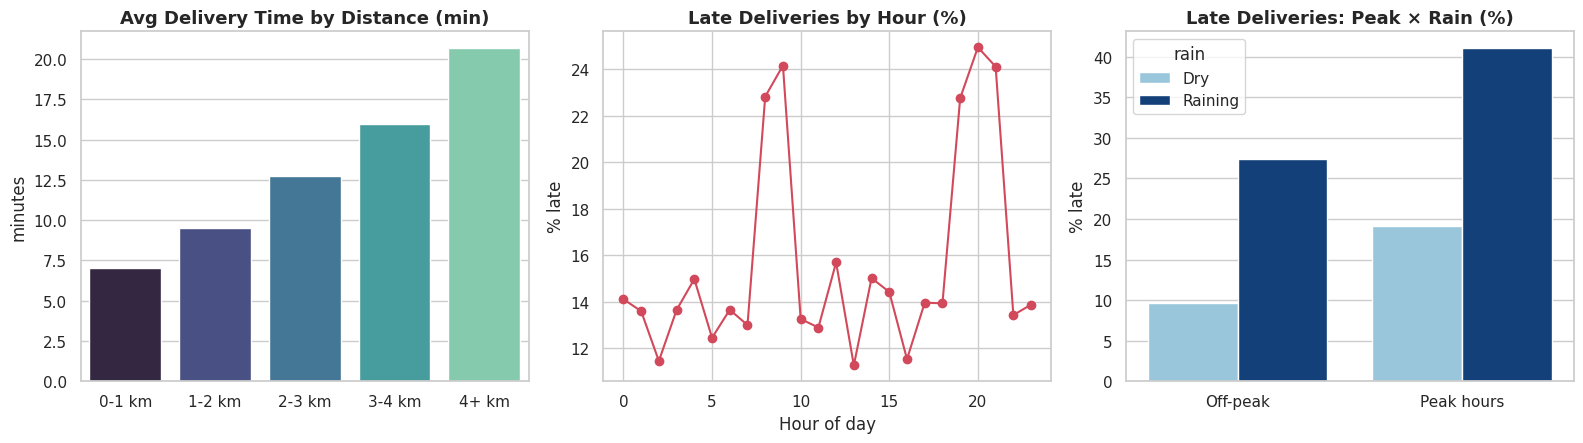

Late rate – rain: 32.7% vs dry: 13.3% | peak: 23.8% vs off-peak: 13.5%


In [ ]:
df["distance_band"] = pd.cut(df["distance_km"], bins=[0, 1, 2, 3, 4, 8],
                             labels=["0-1 km", "1-2 km", "2-3 km", "3-4 km", "4+ km"]).astype(str)
band_order = ["0-1 km", "1-2 km", "2-3 km", "3-4 km", "4+ km"]
by_band = df.groupby("distance_band")["delivery_time_min"].mean().reindex(band_order)
by_hour = df.groupby("hour")["is_delayed"].mean() * 100
cond = (df.assign(rain=np.where(df["is_raining"], "Raining", "Dry"),
                  slot=np.where(df["is_peak"] == 1, "Peak hours", "Off-peak"))
          .groupby(["slot", "rain"])["is_delayed"].mean().mul(100).reset_index())

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
sns.barplot(x=by_band.index, y=by_band.values, ax=axes[0], palette="mako")
axes[0].set_title("Avg Delivery Time by Distance (min)"); axes[0].set_xlabel(""); axes[0].set_ylabel("minutes")
axes[1].plot(by_hour.index, by_hour.values, marker="o", color="#d1495b")
axes[1].set_title("Late Deliveries by Hour (%)"); axes[1].set_xlabel("Hour of day"); axes[1].set_ylabel("% late")
sns.barplot(data=cond, x="slot", y="is_delayed", hue="rain", ax=axes[2], palette=["#8ecae6", "#023e8a"])
axes[2].set_title("Late Deliveries: Peak × Rain (%)"); axes[2].set_xlabel(""); axes[2].set_ylabel("% late")
save_fig("06_delivery_drivers")

rain_gap = df.groupby("is_raining")["is_delayed"].mean()
peak_gap = df.groupby("is_peak")["is_delayed"].mean()
print(f"Late rate – rain: {rain_gap[True]:.1%} vs dry: {rain_gap[False]:.1%} | peak: {peak_gap[1]:.1%} vs off-peak: {peak_gap[0]:.1%}")

### 8.7 Cost of late deliveries – ratings and refunds

,orders,rating,refund_rate
delay_bucket,,,
On time,26361,4.66,0.01
1-3 min late,4696,4.36,0.01
3-6 min late,762,4.11,0.08
6+ min late,141,3.67,0.11


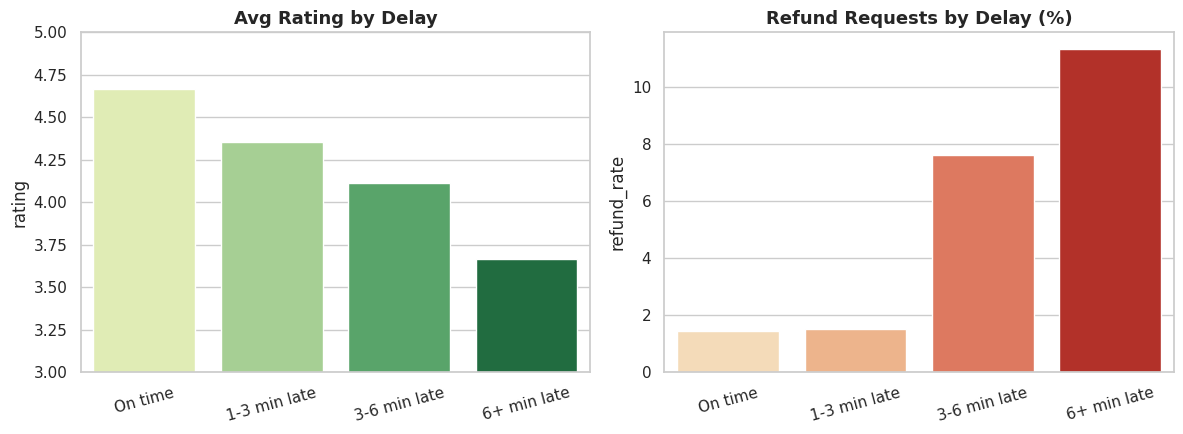

In [ ]:
df["delay_bucket"] = pd.cut(df["delay_min"], bins=[-0.01, 0, 3, 6, 100],
                            labels=["On time", "1-3 min late", "3-6 min late", "6+ min late"]).astype(str)
bucket_order = ["On time", "1-3 min late", "3-6 min late", "6+ min late"]
dl = (df.groupby("delay_bucket")
        .agg(orders=("order_id", "count"), rating=("rating", "mean"), refund_rate=("refund_requested", "mean"))
        .reindex(bucket_order))
display(dl.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.barplot(x=dl.index, y=dl["rating"], ax=axes[0], palette="YlGn")
axes[0].set_ylim(3, 5); axes[0].set_title("Avg Rating by Delay"); axes[0].set_xlabel(""); axes[0].tick_params(axis="x", rotation=15)
sns.barplot(x=dl.index, y=dl["refund_rate"] * 100, ax=axes[1], palette="OrRd")
axes[1].set_title("Refund Requests by Delay (%)"); axes[1].set_xlabel(""); axes[1].tick_params(axis="x", rotation=15)
save_fig("07_delay_cost")

### 8.8 Do members behave differently?

In [ ]:
mem = (df.groupby("is_member")
         .agg(customers=("customer_id", "nunique"), orders=("order_id", "count"), aov=("order_value", "mean"),
              rating=("rating", "mean"), delay_rate=("is_delayed", "mean")))
mem["orders_per_customer"] = mem["orders"] / mem["customers"]
mem.index = mem.index.map({True: "Member", False: "Non-member"})
mem.round(3)

,customers,orders,aov,rating,delay_rate,orders_per_customer
is_member,,,,,,
Non-member,1738,17205,339.62,4.61,0.17,9.90
Member,945,14755,345.83,4.60,0.18,15.61


## 9. AI Model 1 – Customer Segmentation (RFM + K-Means)

**RFM** summarises each customer with three numbers:
**Recency** (days since last order), **Frequency** (number of orders), **Monetary** (total spend).
K-Means then groups customers with similar behaviour automatically – no manual rules.

In [ ]:
snapshot = df["order_date"].max() + pd.Timedelta(days=1)
rfm = (df.groupby("customer_id")
         .agg(recency=("order_date", lambda s: (snapshot - s.max()).days),
              frequency=("order_id", "nunique"),
              monetary=("order_value", "sum"))
         .reset_index())
display(rfm.describe().round(1))

# Log-transform (skewed data) then standardise so no single metric dominates the distance calculation
X_rfm = StandardScaler().fit_transform(np.log1p(rfm[["recency", "frequency", "monetary"]]))

,recency,frequency,monetary
count,"2,683.00","2,683.00","2,683.00"
mean,80.10,11.90,"4,079.70"
std,95.80,13.10,"4,657.50"
min,1.00,1.00,38.10
25%,9.00,3.00,"1,070.00"
50%,33.00,8.00,"2,572.30"
75%,123.00,16.00,"5,352.20"
max,365.00,139.00,"51,189.30"


**Choosing the number of clusters.** We compare inertia (elbow) and silhouette score for k = 2…7.

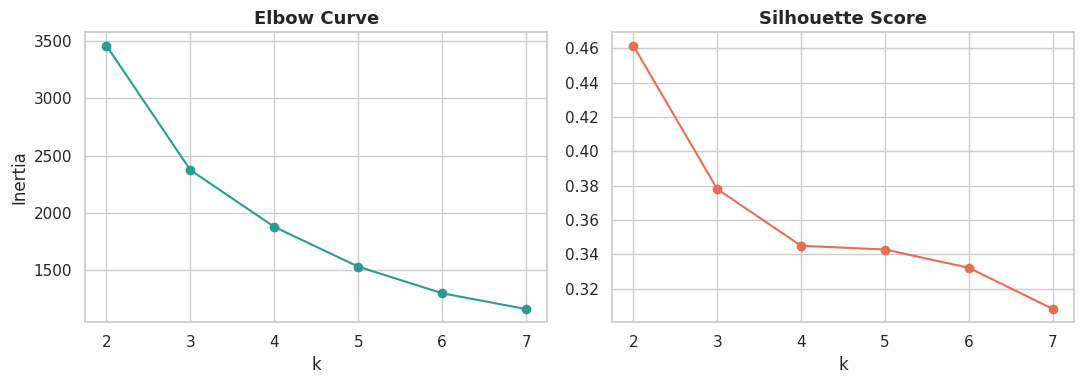

{2: 0.462, 3: 0.378, 4: 0.345, 5: 0.343, 6: 0.332, 7: 0.308}


In [ ]:
ks = range(2, 8)
inertia, sil = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(X_rfm)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X_rfm, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(ks), inertia, marker="o", color="#2a9d8f"); axes[0].set_title("Elbow Curve"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[1].plot(list(ks), sil, marker="o", color="#e76f51"); axes[1].set_title("Silhouette Score"); axes[1].set_xlabel("k")
save_fig("08_kmeans_selection")
print({k: round(s, 3) for k, s in zip(ks, sil)})

Silhouette is highest for k = 2 (just "active" vs "inactive"), which is too coarse to act on. **k = 4** is the smallest
solution that separates *previously-loyal-but-fading* customers from *never-engaged* ones – the distinction that matters
most for retention spend – and still has an acceptable silhouette. We therefore use **k = 4**.

In [ ]:
K = 4
kmeans = KMeans(n_clusters=K, n_init=10, random_state=SEED).fit(X_rfm)
rfm["cluster"] = kmeans.labels_

prof = rfm.groupby("cluster").agg(customers=("customer_id", "count"), recency=("recency", "mean"),
                                  frequency=("frequency", "mean"), monetary=("monetary", "mean"))

# Give each cluster a business name using its RFM profile
names = {}
names[prof["monetary"].idxmax()] = "Champions"
rest = [c for c in prof.index if c not in names]
names[prof.loc[rest, "frequency"].idxmin()] = "Lapsed / Low-Value"
rest = [c for c in prof.index if c not in names]
names[prof.loc[rest, "recency"].idxmax()] = "At-Risk (Fading Regulars)"
rest = [c for c in prof.index if c not in names]
names[rest[0]] = "Active Regulars"

rfm["segment"] = rfm["cluster"].map(names)
seg = (rfm.groupby("segment")
          .agg(customers=("customer_id", "count"), avg_recency_days=("recency", "mean"),
               avg_orders=("frequency", "mean"), avg_spend=("monetary", "mean"), total_spend=("monetary", "sum")))
seg["customer_share_%"] = seg["customers"] / seg["customers"].sum() * 100
seg["revenue_share_%"] = seg["total_spend"] / seg["total_spend"].sum() * 100
seg = seg.sort_values("total_spend", ascending=False)
display(seg.round(1))

,customers,avg_recency_days,avg_orders,avg_spend,total_spend,customer_share_%,revenue_share_%
segment,,,,,,,
Champions,676,12.10,28.70,"10,007.50","6,765,054.60",25.20,61.80
Active Regulars,715,16.00,9.00,"2,982.70","2,132,626.30",26.60,19.50
At-Risk (Fading Regulars),731,125.60,7.00,"2,449.10","1,790,301.10",27.20,16.40
Lapsed / Low-Value,561,184.30,1.70,459.60,"257,857.30",20.90,2.40


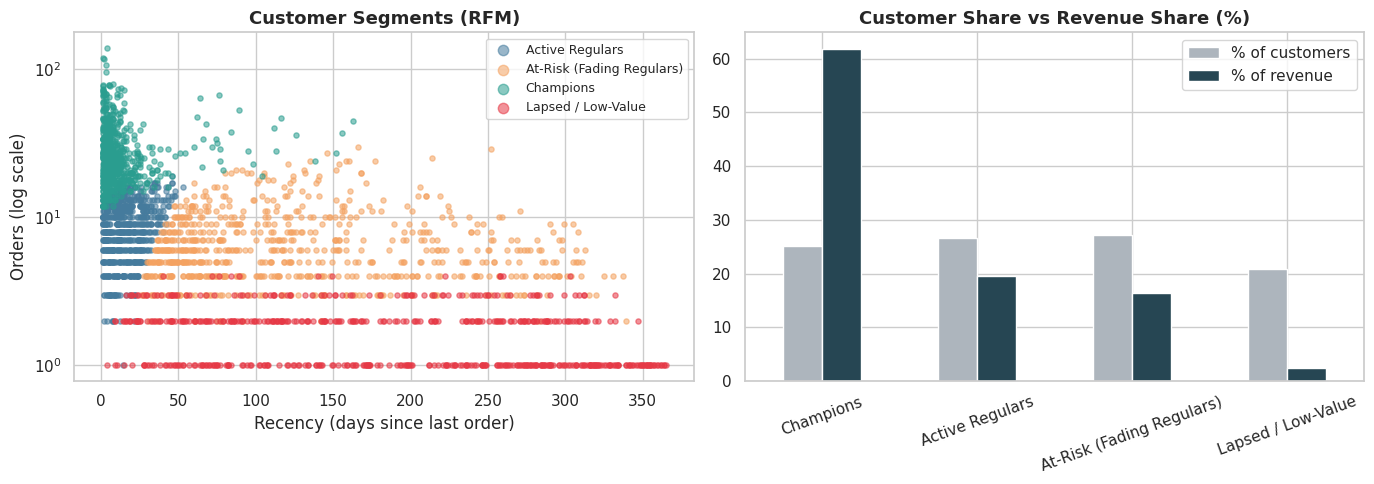

Champions are 25% of customers but 62% of revenue.
At-risk fading regulars: 731 customers, ₹1,790,301 historical spend at stake.


In [ ]:
seg_colors = {"Champions": "#2a9d8f", "Active Regulars": "#457b9d",
              "At-Risk (Fading Regulars)": "#f4a261", "Lapsed / Low-Value": "#e63946"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for s, g in rfm.groupby("segment"):
    axes[0].scatter(g["recency"], g["frequency"], s=14, alpha=0.55, label=s, color=seg_colors[s])
axes[0].set_yscale("log"); axes[0].set_xlabel("Recency (days since last order)"); axes[0].set_ylabel("Orders (log scale)")
axes[0].set_title("Customer Segments (RFM)"); axes[0].legend(markerscale=2, fontsize=9)

share = seg[["customer_share_%", "revenue_share_%"]].reindex(list(seg_colors.keys()))
share.plot.bar(ax=axes[1], color=["#adb5bd", "#264653"])
axes[1].set_title("Customer Share vs Revenue Share (%)"); axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=20); axes[1].legend(["% of customers", "% of revenue"])
save_fig("09_rfm_segments")

champ = seg.loc["Champions"]
risk = seg.loc["At-Risk (Fading Regulars)"]
print(f"Champions are {champ['customer_share_%']:.0f}% of customers but {champ['revenue_share_%']:.0f}% of revenue.")
print(f"At-risk fading regulars: {int(risk['customers'])} customers, ₹{risk['total_spend']:,.0f} historical spend at stake.")

## 10. AI Model 2 – Late-Delivery Prediction (Classification)

**Goal:** predict, at the moment an order is placed, whether it will be delivered later than promised – so ops can
re-route riders, adjust the ETA shown to the customer, or add a buffer.

**Features used (all known before delivery – no data leakage):** distance, items in basket, packing time, hour, peak flag,
rain flag, weekend flag, city, day-part. `delivery_time_min` is deliberately **excluded**.

In [ ]:
num_feats = ["distance_km", "items_count", "prep_time_min", "hour"]
bin_feats = ["is_peak", "is_raining", "is_weekend"]
cat_feats = ["city", "day_part"]

X = df[num_feats + bin_feats + cat_feats].copy()
X["is_raining"] = X["is_raining"].astype(int)
y = df["is_delayed"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=SEED, stratify=y)
print(f"Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows | Late-delivery rate: {y.mean():.1%}")

pre = ColumnTransformer([
    ("num", StandardScaler(), num_feats),
    ("bin", "passthrough", bin_feats),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_feats),
])

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=200, min_samples_leaf=5, class_weight="balanced_subsample",
                                            n_jobs=-1, random_state=SEED),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=150, max_depth=3, learning_rate=0.1, random_state=SEED),
}

results, fitted, probas = [], {}, {}
for name, clf in models.items():
    pipe = Pipeline([("prep", pre), ("model", clf)]).fit(X_train, y_train)
    p = pipe.predict_proba(X_test)[:, 1]
    fitted[name], probas[name] = pipe, p
    pred = (p >= 0.5).astype(int)
    results.append({"Model": name, "Accuracy": accuracy_score(y_test, pred), "Precision": precision_score(y_test, pred),
                    "Recall": recall_score(y_test, pred), "F1": f1_score(y_test, pred), "ROC-AUC": roc_auc_score(y_test, p)})

res = pd.DataFrame(results).set_index("Model")
display(res.round(3))
best_name = res["ROC-AUC"].idxmax()
print(f"\nBest model by ROC-AUC: {best_name}")

Train: 23,970 rows | Test: 7,990 rows | Late-delivery rate: 17.5%


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.75,0.39,0.75,0.51,0.83
Random Forest,0.84,0.53,0.71,0.61,0.88
Gradient Boosting,0.88,0.75,0.50,0.60,0.91



Best model by ROC-AUC: Gradient Boosting


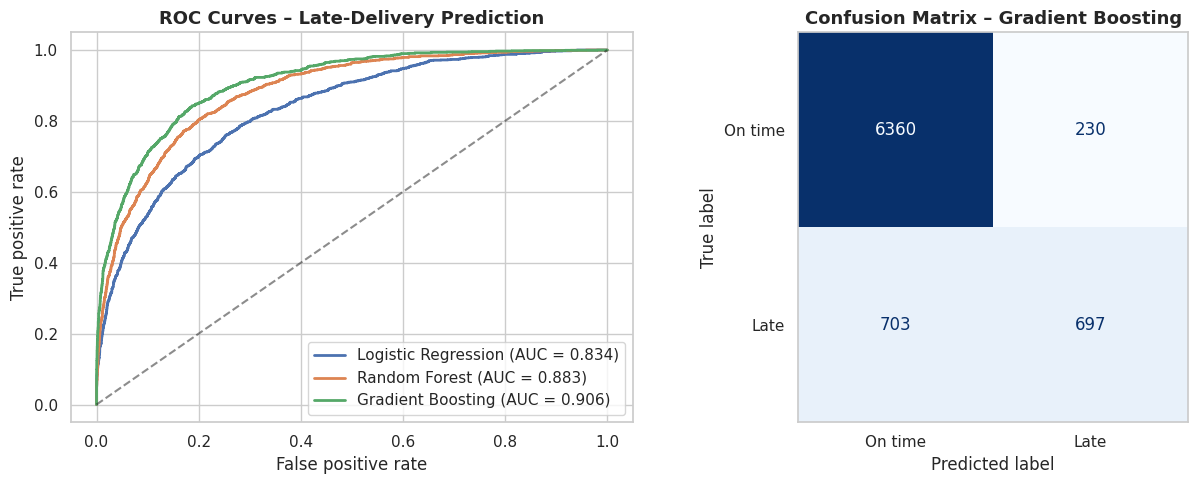

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name, p in probas.items():
    fpr, tpr, _ = roc_curve(y_test, p)
    axes[0].plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {roc_auc_score(y_test, p):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[0].set_title("ROC Curves – Late-Delivery Prediction"); axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate")
axes[0].legend(loc="lower right")

best_pred = (probas[best_name] >= 0.5).astype(int)
ConfusionMatrixDisplay(confusion_matrix(y_test, best_pred), display_labels=["On time", "Late"]).plot(ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title(f"Confusion Matrix – {best_name}"); axes[1].grid(False)
save_fig("10_delay_model")

### What drives late deliveries? (permutation importance)
Permutation importance measures how much the model's ROC-AUC drops when a feature is randomly shuffled – a model-agnostic
way to see which inputs really matter.

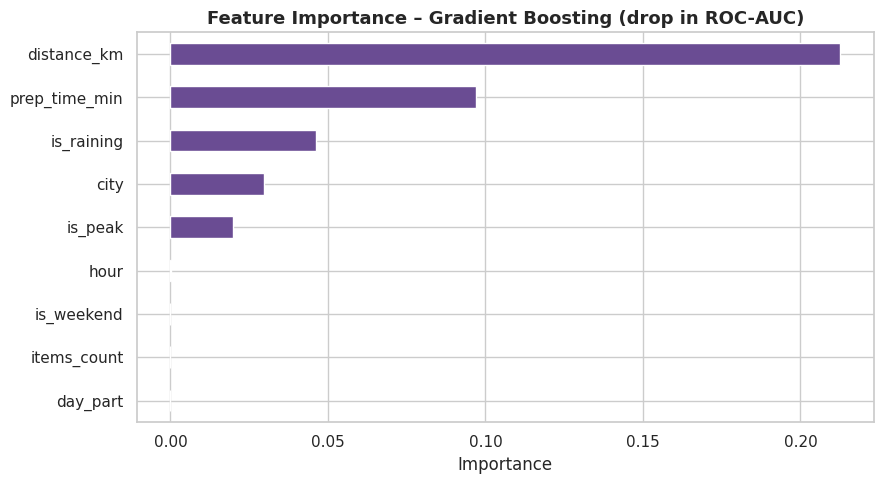

Top drivers of late delivery: distance_km, prep_time_min, is_raining


In [ ]:
best_pipe = fitted[best_name]
perm = permutation_importance(best_pipe, X_test, y_test, scoring="roc_auc", n_repeats=5, random_state=SEED, n_jobs=-1)
imp = pd.Series(perm.importances_mean, index=X_test.columns).sort_values()

plt.figure(figsize=(9, 5))
imp.plot.barh(color="#6a4c93")
plt.title(f"Feature Importance – {best_name} (drop in ROC-AUC)")
plt.xlabel("Importance")
save_fig("11_feature_importance")
top_feats = imp.sort_values(ascending=False).head(3).index.tolist()
print("Top drivers of late delivery:", ", ".join(top_feats))

## 11. AI Model 3 – Daily Demand Forecasting

Rider rosters and dark-store stock are planned a day ahead, so we forecast **daily order volume**. The last 20% of days
(late Oct → Dec, which includes the festive peak) are held out as a test set and four approaches are compared:

| Model | Idea |
|---|---|
| Seasonal naive | "Same as this day last week" |
| 7-day moving average | Average of the previous 7 days |
| Random Forest + lags | Tree model on yesterday / last-week / rolling-average demand |
| **Ridge regression (trend + calendar)** | Growth trend + day-of-week + festive-season effect – all known in advance |

Tree models cannot extrapolate beyond the range they were trained on, so on a growing business they tend to under-predict.
A regularised linear model with an explicit trend term does not have that weakness.

,MAE (orders/day),MAPE %
Seasonal naive (last week),13.60,12.13
7-day moving average,11.09,9.90
Random Forest + lags,12.99,12.26
Ridge (trend + calendar),6.76,6.03


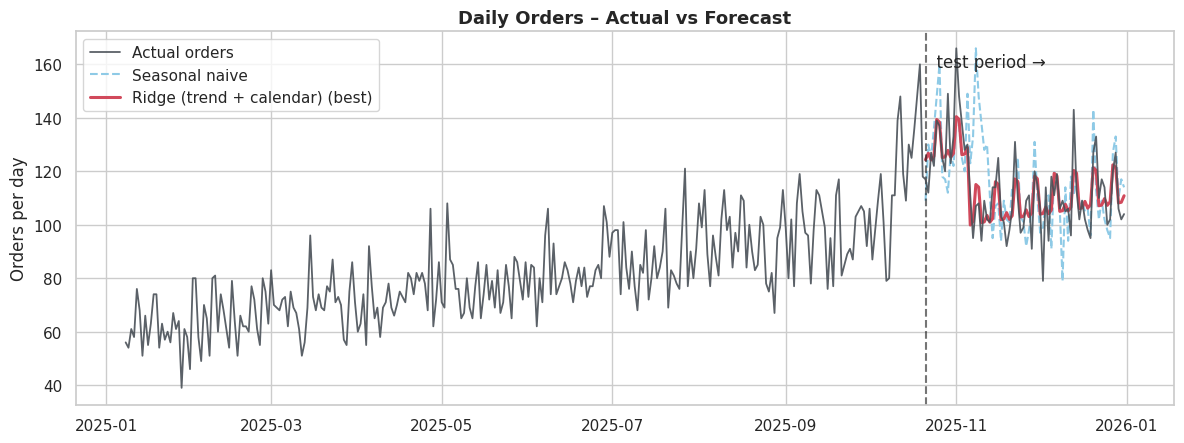

Best model: Ridge (trend + calendar). Its error is 50% lower than the last-week baseline (MAE 6.8 vs 13.6 orders/day).


In [ ]:
daily = df.groupby("order_date").size().asfreq("D", fill_value=0).to_frame("orders")
daily["dow"] = daily.index.dayofweek
daily["is_festive"] = ((daily.index >= "2025-10-10") & (daily.index <= "2025-11-05")).astype(int)
daily["trend"] = np.arange(len(daily))
daily["lag_1"] = daily["orders"].shift(1)
daily["lag_7"] = daily["orders"].shift(7)
daily["roll_7"] = daily["orders"].shift(1).rolling(7).mean()
daily = daily.dropna()

X_cal = pd.concat([pd.get_dummies(daily["dow"], prefix="dow").astype(float), daily[["is_festive", "trend"]]], axis=1)
X_lag = daily[["dow", "is_festive", "trend", "lag_1", "lag_7", "roll_7"]]

split = int(len(daily) * 0.8)
y_tr, y_te = daily["orders"].iloc[:split], daily["orders"].iloc[split:]
test_idx = daily.index[split:]

ridge = Ridge(alpha=1.0).fit(X_cal.iloc[:split], y_tr)
rf = RandomForestRegressor(n_estimators=300, min_samples_leaf=2, random_state=SEED, n_jobs=-1).fit(X_lag.iloc[:split], y_tr)

preds = {
    "Seasonal naive (last week)": daily["lag_7"].iloc[split:].values,
    "7-day moving average": daily["roll_7"].iloc[split:].values,
    "Random Forest + lags": rf.predict(X_lag.iloc[split:]),
    "Ridge (trend + calendar)": ridge.predict(X_cal.iloc[split:]),
}
fc = pd.DataFrame({
    "MAE (orders/day)": {k: mean_absolute_error(y_te, v) for k, v in preds.items()},
    "MAPE %": {k: (np.abs(y_te.values - v) / y_te.values).mean() * 100 for k, v in preds.items()},
})
display(fc.round(2))

best_fc = fc["MAE (orders/day)"].idxmin()
mae_best = fc.loc[best_fc, "MAE (orders/day)"]
mae_naive = fc.loc["Seasonal naive (last week)", "MAE (orders/day)"]
improve = (mae_naive - mae_best) / mae_naive

plt.figure(figsize=(12, 4.6))
plt.plot(daily.index, daily["orders"], color="#495057", linewidth=1.3, alpha=0.9, label="Actual orders", zorder=3)
plt.plot(test_idx, preds["Seasonal naive (last week)"], color="#8ecae6", linestyle="--", label="Seasonal naive")
plt.plot(test_idx, preds[best_fc], color="#d1495b", linewidth=2.2, label=f"{best_fc} (best)")
plt.axvline(test_idx[0], color="k", linestyle="--", alpha=0.6)
plt.text(test_idx[0], daily["orders"].max() * 0.99, "  test period →", va="top")
plt.title("Daily Orders – Actual vs Forecast"); plt.ylabel("Orders per day"); plt.legend(loc="upper left")
save_fig("12_forecast")
print(f"Best model: {best_fc}. Its error is {improve:.0%} lower than the last-week baseline (MAE {mae_best:.1f} vs {mae_naive:.1f} orders/day).")

## 12. AI Model 4 – Automated Insight Engine
A small statistical engine that reads the analysed data and **writes the management summary by itself**. Because it is
computed from the data, the narrative updates automatically whenever the dataset changes (e.g. next month's orders).

In [ ]:
def generate_insights(d, segments, delay_auc, top_drivers):
    out = []
    tot = d["order_value"].sum()

    c = d.groupby("category")["order_value"].sum().sort_values(ascending=False)
    out.append(f"REVENUE MIX: '{c.index[0]}' and '{c.index[1]}' lead revenue with {c.iloc[0]/tot:.0%} and {c.iloc[1]/tot:.0%} "
               f"of sales; top-3 categories together contribute {c.iloc[:3].sum()/tot:.0%}.")

    aov_cat = d.groupby("category")["order_value"].mean().sort_values(ascending=False)
    out.append(f"BASKET VALUE: '{aov_cat.index[0]}' has the highest AOV ({inr(aov_cat.iloc[0])}) vs. '{aov_cat.index[-1]}' "
               f"({inr(aov_cat.iloc[-1])}) – cross-sell high-AOV items into low-AOV baskets.")

    hr = d.groupby("hour").size()
    top_hours = hr.sort_values(ascending=False).head(3).index.sort_values().tolist()
    out.append(f"DEMAND PEAKS: busiest hours are {', '.join(f'{h}:00' for h in top_hours)}; peak windows (8-9 am, 7-9 pm) "
               f"handle {d['is_peak'].mean():.0%} of orders and run a {d[d.is_peak==1]['is_delayed'].mean():.1%} late rate "
               f"vs {d[d.is_peak==0]['is_delayed'].mean():.1%} off-peak.")

    cty = d.groupby("city")["is_delayed"].mean().sort_values()
    out.append(f"CITY RELIABILITY: best on-time city is {cty.index[0]} ({1-cty.iloc[0]:.1%}); weakest is {cty.index[-1]} "
               f"({1-cty.iloc[-1]:.1%}).")

    rn = d.groupby("is_raining")["is_delayed"].mean()
    out.append(f"WEATHER: rain lifts the late-delivery rate from {rn[False]:.1%} to {rn[True]:.1%} "
               f"({rn[True]/rn[False]:.1f}x) – add rider buffer & surge ETA on rainy days.")

    late, ontime = d[d.is_delayed == 1], d[d.is_delayed == 0]
    out.append(f"DELAY COST: late orders get an average rating of {late['rating'].mean():.2f} vs {ontime['rating'].mean():.2f} on-time, "
               f"and refund requests jump from {ontime['refund_requested'].mean():.1%} to {late['refund_requested'].mean():.1%}.")

    m = d.groupby("is_member").agg(aov=("order_value", "mean"), orders=("order_id", "count"), cust=("customer_id", "nunique"))
    out.append(f"MEMBERSHIP: members place {m.loc[True,'orders']/m.loc[True,'cust']:.1f} orders/customer vs "
               f"{m.loc[False,'orders']/m.loc[False,'cust']:.1f} for non-members.")

    corr_ = d[["discount_pct", "gross_value"]].corr().iloc[0, 1]
    out.append(f"DISCOUNTS: discount % vs basket size correlation is {corr_:+.2f}; ₹{d['discount_amount'].sum():,.0f} "
               f"({d['discount_amount'].sum()/d['gross_value'].sum():.1%} of gross sales) was given away without lifting basket value.")

    ch, rk = segments.loc["Champions"], segments.loc["At-Risk (Fading Regulars)"]
    out.append(f"CUSTOMERS: {ch['customer_share_%']:.0f}% of customers (Champions) generate {ch['revenue_share_%']:.0f}% of revenue; "
               f"{int(rk['customers'])} fading regulars hold ₹{rk['total_spend']:,.0f} of historical spend and should be re-engaged now.")

    out.append(f"AI READINESS: the late-delivery model reaches ROC-AUC {delay_auc:.2f}; main drivers are {', '.join(top_drivers)}.")
    return out


insights = generate_insights(df, seg, res.loc[best_name, "ROC-AUC"], top_feats)
for i, line in enumerate(insights, 1):
    print(f"{i}. {line}\n")

1. REVENUE MIX: 'Electronics & Accessories' and 'Fruits & Vegetables' lead revenue with 18% and 11% of sales; top-3 categories together contribute 40%.

2. BASKET VALUE: 'Electronics & Accessories' has the highest AOV (₹1,077) vs. 'Dairy & Bread' (₹183) – cross-sell high-AOV items into low-AOV baskets.

3. DEMAND PEAKS: busiest hours are 19:00, 20:00, 21:00; peak windows (8-9 am, 7-9 pm) handle 39% of orders and run a 23.8% late rate vs 13.5% off-peak.

4. CITY RELIABILITY: best on-time city is Pune (90.7%); weakest is Bengaluru (74.3%).

5. WEATHER: rain lifts the late-delivery rate from 13.3% to 32.7% (2.5x) – add rider buffer & surge ETA on rainy days.

6. DELAY COST: late orders get an average rating of 4.31 vs 4.66 on-time, and refund requests jump from 1.5% to 2.6%.

7. MEMBERSHIP: members place 15.6 orders/customer vs 9.9 for non-members.

8. DISCOUNTS: discount % vs basket size correlation is +0.00; ₹608,165 (5.3% of gross sales) was given away without lifting basket value.

9.

## 13. Business Recommendations
Generated from the results above (numbers update if the data changes).

In [ ]:
aov_cat_top = cat["aov"].idxmax()
recs = [
    f"1. **Fix peak-hour & rain reliability first.** Late rate is {peak_gap[1]:.1%} at peak and {rain_gap[True]:.1%} in rain. "
    f"Use the delay model ({best_name}, AUC {res.loc[best_name, 'ROC-AUC']:.2f}) to add a rider buffer or show a longer ETA for high-risk orders.",
    f"2. **Replace blanket discounts with targeted offers.** Discounts show no link to basket size (corr {corr:+.2f}) and cost {inr(disc_leak)}. "
    f"Test targeted alternatives instead (e.g. free-delivery threshold, category bundles) and measure incremental basket size.",
    f"3. **Launch a win-back campaign for '{risk.name}'.** {int(risk['customers'])} customers with {inr(risk['total_spend'])} historical spend.",
    f"4. **Protect Champions.** They are {champ['customer_share_%']:.0f}% of customers but {champ['revenue_share_%']:.0f}% of revenue – give priority delivery and early access.",
    f"5. **Staff by forecast.** The {best_fc} model cuts planning error by {improve:.0%} vs the last-week baseline "
    f"(MAE {mae_best:.0f} orders/day) – use it for next-day rider rosters and stock.",
    f"6. **Grow the high-AOV categories** ('{aov_cat_top}') via cross-sell prompts at checkout.",
]
from IPython.display import Markdown
Markdown("\n\n".join(recs))

1. **Fix peak-hour & rain reliability first.** Late rate is 23.8% at peak and 32.7% in rain. Use the delay model (Gradient Boosting, AUC 0.91) to add a rider buffer or show a longer ETA for high-risk orders.

2. **Replace blanket discounts with targeted offers.** Discounts show no link to basket size (corr +0.00) and cost ₹608,165. Test targeted alternatives instead (e.g. free-delivery threshold, category bundles) and measure incremental basket size.

3. **Launch a win-back campaign for 'At-Risk (Fading Regulars)'.** 731 customers with ₹1,790,301 historical spend.

4. **Protect Champions.** They are 25% of customers but 62% of revenue – give priority delivery and early access.

5. **Staff by forecast.** The Ridge (trend + calendar) model cuts planning error by 50% vs the last-week baseline (MAE 7 orders/day) – use it for next-day rider rosters and stock.

6. **Grow the high-AOV categories** ('Electronics & Accessories') via cross-sell prompts at checkout.

## 14. Save Outputs & Conclusion

In [ ]:
df.to_csv("data/blinkit_orders_clean.csv", index=False)
rfm.to_csv("data/customer_segments_rfm.csv", index=False)
pd.Series(insights).to_csv("data/auto_insights.csv", index=False, header=["insight"])
print("Saved: data/blinkit_orders_clean.csv, data/customer_segments_rfm.csv, data/auto_insights.csv")
print("Charts saved in ./charts/:", len(os.listdir("charts")), "files")

Saved: data/blinkit_orders_clean.csv, data/customer_segments_rfm.csv, data/auto_insights.csv
Charts saved in ./charts/: 12 files


### Conclusion
This project delivered an end-to-end analytics and AI workflow for a quick-commerce business:

* **Descriptive analytics** – KPIs, category/city/time analysis, discount and delivery-quality diagnostics.
* **Predictive analytics** – late-delivery classification and daily-demand forecasting that beat simple baselines.
* **Prescriptive analytics** – RFM customer segments, an automated insight engine and concrete recommendations.

**Limitations & future work:** the data is synthetic, so absolute numbers are illustrative – the *methodology* is what transfers.
Next steps: run on real order logs, add SKU-level basket analysis, a rider-level dataset, a Streamlit dashboard, and an
LLM layer that lets managers ask questions in plain English.